In [ ]:
import os
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt

In [2]:
if Path.cwd().name == "notebooks":
    os.chdir("..")
print(Path.cwd())

/Users/majdalsuleh/Projects/mining-quality-prediction


In [3]:
con = duckdb.connect("data/mining.duckdb")

con.execute("""
    CREATE OR REPLACE TABLE raw AS
    SELECT *
    FROM read_csv('data/MiningProcess_Flotation_Plant_Database.csv',
                  header = true,
                  decimal_separator = ',')
""")

con.sql("DESCRIBE raw")

┌──────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │ column_type │  null   │   key   │ default │  extra  │
│           varchar            │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ date                         │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ % Iron Feed                  │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ % Silica Feed                │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Starch Flow                  │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Amina Flow                   │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Ore Pulp Flow                │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Ore Pulp pH                  │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Ore Pulp Density             │ DOUBLE    

In [4]:
con.sql("SELECT COUNT(*) AS rows, MIN(date), MAX(date) FROM raw")

┌────────┬─────────────────────┬─────────────────────┐
│  rows  │      min(date)      │      max(date)      │
│ int64  │      timestamp      │      timestamp      │
├────────┼─────────────────────┼─────────────────────┤
│ 737453 │ 2017-03-10 01:00:00 │ 2017-09-09 23:00:00 │
└────────┴─────────────────────┴─────────────────────┘

In [5]:
con.execute(open("sql/01_hourly_table.sql").read())
con.sql("SELECT COUNT(*) AS hours, SUM(is_filled::INT) AS filled_hours FROM hourly")

┌───────┬──────────────┐
│ hours │ filled_hours │
│ int64 │    int128    │
├───────┼──────────────┤
│  4097 │          448 │
└───────┴──────────────┘

In [6]:
con.sql("SELECT * FROM hourly LIMIT 5")

┌─────────────────────┬────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬───────────┐
│        hour         │ n_readings │     iron_feed      │    silica_feed     │    starch_flow     │    amina_flow     │     pulp_flow      │      pulp_ph       │    pulp_density    │       air_01       │       air_02       │       air_03       │       air_04       │       air_05       │       air_06       │       air_07       │      level_01      │      level_02      │      level_03      │     level_04      │      level_05      │      level_06      │      level_07   

In [7]:
def run(path):
    return con.sql(open(path).read())

In [8]:
con.execute(open("sql/02_clean_view.sql").read())
con.sql("SELECT COUNT(*) AS clean_hours FROM clean")

┌─────────────┐
│ clean_hours │
│    int64    │
├─────────────┤
│        3509 │
└─────────────┘

In [9]:
run("sql/03_monthly_quality.sql")

┌─────────────────────┬───────┬────────────┬────────────┬────────────┐
│        month        │ hours │ avg_silica │ min_silica │ max_silica │
│      timestamp      │ int64 │   double   │   double   │   double   │
├─────────────────────┼───────┼────────────┼────────────┼────────────┤
│ 2017-03-01 00:00:00 │    54 │       2.63 │       1.02 │        5.5 │
│ 2017-04-01 00:00:00 │   592 │       2.57 │       0.77 │        5.4 │
│ 2017-05-01 00:00:00 │   672 │       2.38 │       0.85 │       5.51 │
│ 2017-06-01 00:00:00 │   684 │       2.02 │       0.86 │       5.47 │
│ 2017-07-01 00:00:00 │   693 │       2.02 │       0.94 │       5.53 │
│ 2017-08-01 00:00:00 │   623 │       2.27 │        0.6 │       5.53 │
│ 2017-09-01 00:00:00 │   191 │        2.5 │       0.94 │        5.3 │
└─────────────────────┴───────┴────────────┴────────────┴────────────┘

In [10]:
run("sql/04_high_silica_share.sql")

┌─────────┬─────────────┬────────────┬───────┬──────────┐
│  month  │ high_cutoff │ high_hours │ hours │ pct_high │
│ varchar │   double    │   int128   │ int64 │  double  │
├─────────┼─────────────┼────────────┼───────┼──────────┤
│ 2017-03 │        2.82 │         18 │    54 │     33.3 │
│ 2017-04 │        2.82 │        203 │   592 │     34.3 │
│ 2017-05 │        2.82 │        213 │   672 │     31.7 │
│ 2017-06 │        2.82 │         96 │   684 │     14.0 │
│ 2017-07 │        2.82 │        128 │   693 │     18.5 │
│ 2017-08 │        2.82 │        160 │   623 │     25.7 │
│ 2017-09 │        2.82 │         59 │   191 │     30.9 │
└─────────┴─────────────┴────────────┴───────┴──────────┘

In [11]:
run("sql/05_settings_high_vs_normal.sql")

┌─────────┬───────┬────────────┬─────────────┬─────────┬────────┬────────┬──────────┬──────────┐
│ quality │ hours │ amina_flow │ starch_flow │ pulp_ph │ air_01 │ air_03 │ level_04 │ level_05 │
│ varchar │ int64 │   double   │   double    │ double  │ double │ double │  double  │  double  │
├─────────┼───────┼────────────┼─────────────┼─────────┼────────┼────────┼──────────┼──────────┤
│ high    │   877 │      519.0 │      2870.6 │    9.72 │  277.5 │  278.5 │    391.1 │    394.1 │
│ normal  │  2632 │      487.4 │      2972.5 │     9.8 │  285.2 │  285.9 │    422.1 │    424.7 │
└─────────┴───────┴────────────┴─────────────┴─────────┴────────┴────────┴──────────┴──────────┘

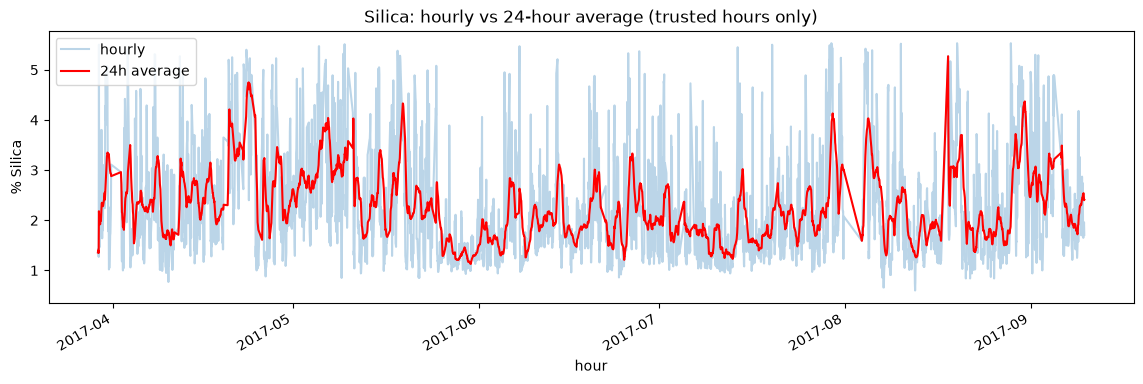

In [12]:
rolling = run("sql/06_rolling_24h.sql").df()

ax = rolling.plot(x="hour", y="silica", figsize=(14, 4), alpha=0.3, label="hourly")
rolling.plot(x="hour", y="silica_24h_avg", ax=ax, color="red", label="24h average")
plt.ylabel("% Silica")
plt.title("Silica: hourly vs 24-hour average (trusted hours only)")
plt.show()

In [13]:
run("sql/07_worst_days.sql")

┌───────┬────────────┬───────┬────────────┐
│ rank  │    day     │ hours │ avg_silica │
│ int64 │    date    │ int64 │   double   │
├───────┼────────────┼───────┼────────────┤
│     1 │ 2017-04-23 │    20 │       4.53 │
│     2 │ 2017-08-30 │    24 │        4.3 │
│     3 │ 2017-07-29 │    24 │       4.05 │
│     4 │ 2017-08-04 │    24 │       4.03 │
│     5 │ 2017-05-06 │    18 │       3.97 │
│     6 │ 2017-04-20 │    21 │       3.81 │
│     7 │ 2017-05-05 │    24 │       3.67 │
│     8 │ 2017-05-18 │    23 │       3.56 │
│     9 │ 2017-04-21 │    24 │       3.31 │
│    10 │ 2017-04-28 │    17 │       3.27 │
└───────┴────────────┴───────┴────────────┘
  10 rows                       4 columns